## Installing the dependencies

In [ ]:
!pip install -q librosa soundfile scikit-learn seaborn kaggle

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_score,recall_score,\
                             f1_score, roc_auc_score, confusion_matrix,classification_report)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,MaxPooling2D,BatchNormalization,Dropout,Flatten,Dense,LSTM,Bidirectional)

from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Kaggle Data download

In [ ]:
from google.colab import userdata
import os

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

In [ ]:
!mkdir -p /content/kaggle_downloads

!kaggle datasets download \
    -d andreadiubaldo/wavefake-test \
    -p /content/kaggle_downloads

Dataset URL: https://www.kaggle.com/datasets/andreadiubaldo/wavefake-test
License(s): unknown
100% 26.9G/26.9G [12:59<00:00, 37.1MB/s]



In [ ]:
!mkdir -p /content/wavefake_required

!unzip -q \
    /content/kaggle_downloads/wavefake-test.zip \
    "generated_audio/ljspeech_melgan/*" \
    -d /content/wavefake_required

In [ ]:
!find /content/wavefake_required -type f -name "*.wav" | wc -l

13100


In [ ]:
!find /content/wavefake_required -type f -name "*.wav" | head -10

/content/wavefake_required/generated_audio/ljspeech_melgan/LJ001-0001_gen.wav
/content/wavefake_required/generated_audio/ljspeech_melgan/LJ001-0002_gen.wav
/content/wavefake_required/generated_audio/ljspeech_melgan/LJ001-0003_gen.wav
/content/wavefake_required/generated_audio/ljspeech_melgan/LJ001-0004_gen.wav
/content/wavefake_required/generated_audio/ljspeech_melgan/LJ001-0005_gen.wav
/content/wavefake_required/generated_audio/ljspeech_melgan/LJ001-0006_gen.wav
/content/wavefake_required/generated_audio/ljspeech_melgan/LJ001-0007_gen.wav
/content/wavefake_required/generated_audio/ljspeech_melgan/LJ001-0008_gen.wav
/content/wavefake_required/generated_audio/ljspeech_melgan/LJ001-0009_gen.wav
/content/wavefake_required/generated_audio/ljspeech_melgan/LJ001-0010_gen.wav


In [ ]:
!rm -f /content/kaggle_downloads/wavefake-test.zip

In [ ]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   51G   62G  46% /


In [ ]:
!kaggle datasets download \
    -d mathurinache/the-lj-speech-dataset \
    -p /content/kaggle_downloads

Dataset URL: https://www.kaggle.com/datasets/mathurinache/the-lj-speech-dataset
License(s): CC0-1.0
100% 2.99G/2.99G [01:22<00:00, 38.9MB/s]



In [ ]:
!mkdir -p /content/ljspeech_required

!unzip -q \
    /content/kaggle_downloads/the-lj-speech-dataset.zip \
    "LJSpeech-1.1/wavs/*" \
    -d /content/ljspeech_required

In [ ]:
!find /content/ljspeech_required -type f -name "*.wav" | wc -l

13100


In [ ]:
!find /content/ljspeech_required -type f -name "*.wav" | head -10

/content/ljspeech_required/LJSpeech-1.1/wavs/LJ001-0001.wav
/content/ljspeech_required/LJSpeech-1.1/wavs/LJ001-0002.wav
/content/ljspeech_required/LJSpeech-1.1/wavs/LJ001-0003.wav
/content/ljspeech_required/LJSpeech-1.1/wavs/LJ001-0004.wav
/content/ljspeech_required/LJSpeech-1.1/wavs/LJ001-0005.wav
/content/ljspeech_required/LJSpeech-1.1/wavs/LJ001-0006.wav
/content/ljspeech_required/LJSpeech-1.1/wavs/LJ001-0007.wav
/content/ljspeech_required/LJSpeech-1.1/wavs/LJ001-0008.wav
/content/ljspeech_required/LJSpeech-1.1/wavs/LJ001-0009.wav
/content/ljspeech_required/LJSpeech-1.1/wavs/LJ001-0010.wav


In [ ]:
!rm -f /content/kaggle_downloads/the-lj-speech-dataset.zip

In [ ]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   55G   59G  49% /


## EDA

In [ ]:
import os

real_dir = "/content/ljspeech_required/LJSpeech-1.1/wavs"
fake_dir = "/content/wavefake_required/generated_audio/ljspeech_melgan"

real_files = {
    os.path.splitext(f)[0]
    for f in os.listdir(real_dir)
    if f.lower().endswith(".wav")
}

fake_files = {
    os.path.splitext(f)[0].replace("_gen", "")
    for f in os.listdir(fake_dir)
    if f.lower().endswith(".wav")
}

print("Real files :", len(real_files))
print("Fake files :", len(fake_files))
print("Matching  :", len(real_files & fake_files))
print("Only real :", len(real_files - fake_files))
print("Only fake :", len(fake_files - real_files))

Real files : 13100
Fake files : 13100
Matching  : 13100
Only real : 0
Only fake : 0


In [ ]:
import os
import numpy as np
import librosa
from tqdm.auto import tqdm

REAL_DIR = "/content/ljspeech_required/LJSpeech-1.1/wavs"
FAKE_DIR = "/content/wavefake_required/generated_audio/ljspeech_melgan"

SAMPLE_RATE = 16000
N_MFCC = 40
MAX_LEN = 500


def extract_mfcc(file_path):
    """
    Extract 40 MFCC coefficients from an audio file
    and pad/truncate to exactly 500 frames.
    """

    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)

    mfcc = librosa.feature.mfcc(y=audio,sr=SAMPLE_RATE,n_mfcc=N_MFCC)

    if mfcc.shape[1] < MAX_LEN:
        mfcc = np.pad(mfcc,((0, 0), (0, MAX_LEN - mfcc.shape[1])),mode="constant")
    else:
        mfcc = mfcc[:, :MAX_LEN]

    return mfcc.astype(np.float32)

In [ ]:
real_test = os.path.join(REAL_DIR, "LJ001-0001.wav")
fake_test = os.path.join(FAKE_DIR, "LJ001-0001_gen.wav")

real_mfcc = extract_mfcc(real_test)
fake_mfcc = extract_mfcc(fake_test)

print("Real MFCC shape:", real_mfcc.shape)
print("Fake MFCC shape:", fake_mfcc.shape)
print("Real dtype:", real_mfcc.dtype)
print("Fake dtype:", fake_mfcc.dtype)

Real MFCC shape: (40, 500)
Fake MFCC shape: (40, 500)
Real dtype: float32
Fake dtype: float32


In [ ]:
from tqdm.auto import tqdm
import os
import numpy as np

real_files = sorted([
    os.path.join(REAL_DIR, f)
    for f in os.listdir(REAL_DIR)
    if f.lower().endswith(".wav")
])

fake_files = sorted([
    os.path.join(FAKE_DIR, f)
    for f in os.listdir(FAKE_DIR)
    if f.lower().endswith(".wav")
])

print("Real files:", len(real_files))
print("Fake files:", len(fake_files))

Real files: 13100
Fake files: 13100


In [ ]:
X = []
y = []

# Real = 0
print("Extracting REAL MFCCs")

for file_path in tqdm(real_files):
    try:
        mfcc = extract_mfcc(file_path)
        X.append(mfcc)
        y.append(0)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Fake = 1
print("\nExtracting FAKE MFCCs")

for file_path in tqdm(fake_files):
    try:
        mfcc = extract_mfcc(file_path)
        X.append(mfcc)
        y.append(1)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

Extracting REAL MFCCs...


  0%|          | 0/13100 [00:00<?, ?it/s]


Extracting FAKE MFCCs...


  0%|          | 0/13100 [00:00<?, ?it/s]

In [ ]:
X = np.stack(X).astype(np.float32)
y = np.array(y, dtype=np.int64)

print("X shape:", X.shape)
print("X dtype:", X.dtype)
print("y shape:", y.shape)

print("\nClass distribution:")
print("Real (0):", np.sum(y == 0))
print("Fake (1):", np.sum(y == 1))

print("\nMemory used by X:", round(X.nbytes / (1024**3), 2), "GB")

X shape: (26200, 40, 500)
X dtype: float32
y shape: (26200,)

Class distribution:
Real (0): 13100
Fake (1): 13100

Memory used by X: 1.95 GB


## Modelling

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining distribution:")
print("Real:", np.sum(y_train == 0))
print("Fake:", np.sum(y_train == 1))

print("\nTesting distribution:")
print("Real:", np.sum(y_test == 0))
print("Fake:", np.sum(y_test == 1))

X_train: (20960, 40, 500)
X_test : (5240, 40, 500)
y_train: (20960,)
y_test : (5240,)

Training distribution:
Real: 10480
Fake: 10480

Testing distribution:
Real: 2620
Fake: 2620


In [ ]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (20960, 40, 500, 1)
X_test : (5240, 40, 500, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential, regularizers

model = Sequential([
    layers.Reshape((40, 500, 1), input_shape=X_train.shape[1:]),

    # CNN Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # CNN → sequence
    layers.Reshape((-1, 128)),

    # BiLSTM 1
    layers.Bidirectional(layers.LSTM(128,return_sequences=True, dropout=0.3, recurrent_dropout=0.0)),
    layers.BatchNormalization(),

    # BiLSTM 2
    layers.Bidirectional(layers.LSTM(128, dropout=0.3, recurrent_dropout=0.0)),
    layers.BatchNormalization(),

    # Classification head
    layers.Dense(128,activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_2 (Reshape)             │ (None, 40, 500, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 40, 500, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 40, 500, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 20, 250, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 250, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 20, 250, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 125, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 125, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 10, 125, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 62, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 310, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 310, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 310, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 786,049 (3.00 MB)

 Trainable params: 784,577 (2.99 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
import time

start = time.time()

test_result = model.fit(X_train[:1024],y_train[:1024], epochs=1, batch_size=64, verbose=1)

elapsed = time.time() - start

print(f"\nTime for 1024 samples: {elapsed:.2f} seconds")

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 158ms/step - accuracy: 0.5078 - loss: 1.1170

Time for 1024 samples: 9.53 seconds


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.2, callbacks=[early_stopping], verbose=1)

Epoch 1/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 46s 175ms/step - accuracy: 0.4986 - loss: 0.9342 - val_accuracy: 0.5031 - val_loss: 0.8178
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 46s 174ms/step - accuracy: 0.4885 - loss: 0.8249 - val_accuracy: 0.5367 - val_loss: 0.7811
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 45s 172ms/step - accuracy: 0.5106 - loss: 0.7781 - val_accuracy: 0.5382 - val_loss: 0.7563
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 45s 173ms/step - accuracy: 0.5686 - loss: 0.7378 - val_accuracy: 0.6283 - val_loss: 0.7074
Epoch 5/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 45s 173ms/step - accuracy: 0.6442 - loss: 0.6759 - val_accuracy: 0.6004 - val_loss: 0.6754
Epoch 6/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 45s 173ms/step - accuracy: 0.7348 - loss: 0.5685 - val_accuracy: 0.7359 - val_loss: 0.5422
Epoch 7/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 45s 173ms/step - accuracy: 0.8166 - loss: 0.4320 - val_accuracy: 0.8740 - val_loss: 0.3402
Epoch 8/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 47s 181ms/step - accuracy: 0.8672 -

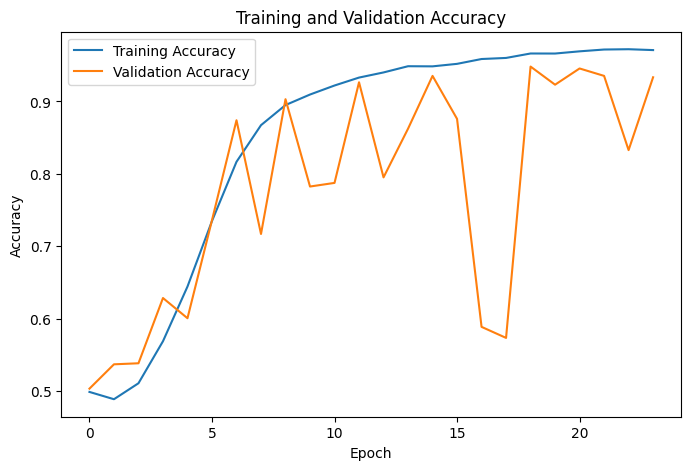

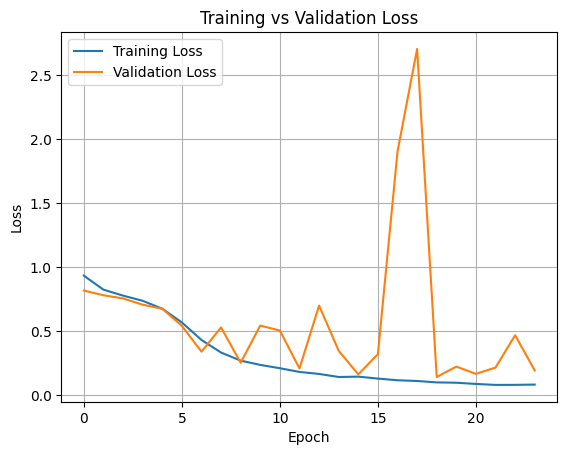

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()


plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("Training stopped at epoch:", len(history.history["loss"]))

best_epoch = np.argmin(history.history["val_loss"]) + 1
best_val_loss = min(history.history["val_loss"])
best_val_acc = history.history["val_accuracy"][best_epoch - 1]

print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Validation accuracy at best epoch:", best_val_acc)

Training stopped at epoch: 24
Best epoch: 19
Best validation loss: 0.14224906265735626
Validation accuracy at best epoch: 0.9482347369194031


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, batch_size=64, verbose=1)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.9546 - loss: 0.1346

Test Loss: 0.1346
Test Accuracy: 0.9546
Test Accuracy: 95.46%


In [ ]:
y_prob = model.predict(X_test,batch_size=64,verbose=1).ravel()

y_pred = (y_prob >= 0.5).astype(int)

print("Predictions generated.")
print("Prediction shape:", y_pred.shape)
print("Probability shape:", y_prob.shape)

82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step
Predictions generated.
Prediction shape: (5240,)
Probability shape: (5240,)


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, classification_report)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("TEST RESULTS: ")
print(f"Accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=["Real", "Fake"], digits=4))

TEST RESULTS: 
Accuracy : 0.9546  (95.46%)
Precision: 0.9491
Recall   : 0.9607
F1-score : 0.9549
ROC-AUC  : 0.9919

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Real     0.9602    0.9485    0.9543      2620
        Fake     0.9491    0.9607    0.9549      2620

    accuracy                         0.9546      5240
   macro avg     0.9546    0.9546    0.9546      5240
weighted avg     0.9546    0.9546    0.9546      5240



Confusion Matrix:
[[2485  135]
 [ 103 2517]]


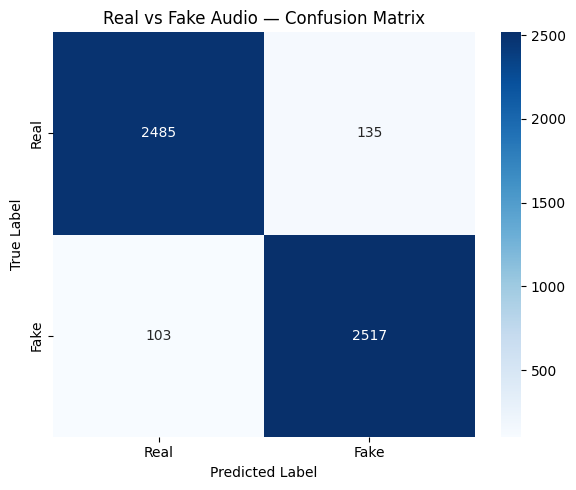

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Real", "Fake"],yticklabels=["Real", "Fake"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Real vs Fake Audio : Confusion Matrix")
plt.tight_layout()
plt.show()

## Save the model

In [ ]:
model_path = "/content/deepfake_audio_cnn_bilstm.keras"

model.save(model_path)

print(model_path)

Model saved successfully!
/content/deepfake_audio_cnn_bilstm.keras


In [ ]:
import pickle

history_path = "/content/training_history.pkl"

with open(history_path, "wb") as f:
    pickle.dump(history.history, f)

print(history_path)

History saved: /content/training_history.pkl


In [ ]:
np.save("/content/X_test.npy", X_test)
np.save("/content/y_test.npy", y_test)

print("Test data saved.")

Test data saved.


## Model Evaluation

In [ ]:
import numpy as np
import librosa


SAMPLE_RATE = 16000
N_MFCC = 40
MAX_LEN = 500


def prepare_audio(file_path):

    # Load audio
    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)

    # Extract MFCC
    mfcc = librosa.feature.mfcc( y=audio, sr=SAMPLE_RATE, n_mfcc=N_MFCC)

    # Keep original MFCC for visualization
    original_mfcc = mfcc.copy()

    # Pad or truncate for model
    if mfcc.shape[1] < MAX_LEN:

        mfcc_model = np.pad(mfcc, ((0, 0), (0, MAX_LEN - mfcc.shape[1])), mode="constant")

    else:

        mfcc_model = mfcc[:, :MAX_LEN]

    # Convert to float32
    mfcc_model = mfcc_model.astype(np.float32)

    # Add batch + channel dimensions
    model_input = mfcc_model[np.newaxis, ..., np.newaxis]

    return audio, sr, original_mfcc, model_input

In [ ]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display


def evaluate_audio(file_path):
    """
    Complete single-audio deepfake evaluation pipeline.
    """

    # Load audio
    audio, sr = librosa.load(file_path,sr=16000)

    duration = len(audio) / sr

    # Extract MFCC
    mfcc = librosa.feature.mfcc(y=audio,sr=16000,n_mfcc=40)

    original_frames = mfcc.shape[1]

    # Pad / truncate
    if original_frames < 500:
        mfcc_input = np.pad(mfcc, ((0, 0), (0, 500 - original_frames)),mode="constant")
    else:
        mfcc_input = mfcc[:, :500]

    # Prepare model input
    X_input = mfcc_input.astype(np.float32)
    X_input = X_input[np.newaxis, ..., np.newaxis]

    # Prediction
    fake_probability = float(model.predict(X_input, verbose=0)[0][0])

    real_probability = 1 - fake_probability

    if fake_probability >= 0.5:
        prediction = "FAKE"
        confidence = fake_probability
    else:
        prediction = "REAL"
        confidence = real_probability

    # Display audio

    print("AUDIO INFORMATION")
    print("." * 60)
    print("File:", os.path.basename(file_path))
    print(f"Sample rate: {sr} Hz")
    print(f"Duration: {duration:.2f} seconds")
    print()

    display(Audio(file_path))

    # Display result
    print("DEEPFAKE DETECTION RESULT")
    print("." * 60)
    print(f"Prediction       : {prediction}")
    print(f"Real probability : {real_probability * 100:.2f}%")
    print(f"Fake probability : {fake_probability * 100:.2f}%")
    print(f"Confidence       : {confidence * 100:.2f}%")

    # MFCC visualization
    plt.figure(figsize=(12, 5))

    librosa.display.specshow(mfcc, x_axis="time", sr=sr)

    plt.colorbar()
    plt.xlabel("Time (seconds)")
    plt.ylabel("MFCC Coefficient")
    plt.title(f"MFCC Representation - Prediction: {prediction}")
    plt.tight_layout()
    plt.show()

    return {
        "file": os.path.basename(file_path),
        "prediction": prediction,
        "real_probability": real_probability, "fake_probability": fake_probability,
        "confidence": confidence
    }

AUDIO INFORMATION
------------------------------------------------------------
File: LJ001-0001.wav
Sample rate: 16000 Hz
Duration: 9.66 seconds



DEEPFAKE DETECTION RESULT
------------------------------------------------------------
Prediction       : REAL
Real probability : 99.99%
Fake probability : 0.01%
Confidence       : 99.99%


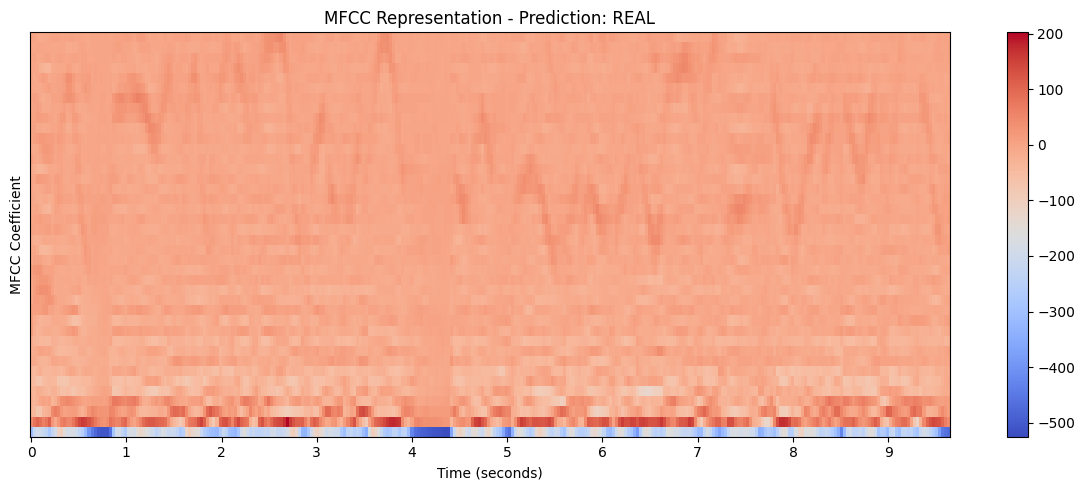

In [ ]:
result_real = evaluate_audio("/content/ljspeech_required/LJSpeech-1.1/wavs/LJ001-0001.wav")

AUDIO INFORMATION
------------------------------------------------------------
File: LJ001-0001_gen.wav
Sample rate: 16000 Hz
Duration: 9.66 seconds



DEEPFAKE DETECTION RESULT
------------------------------------------------------------
Prediction       : FAKE
Real probability : 1.24%
Fake probability : 98.76%
Confidence       : 98.76%


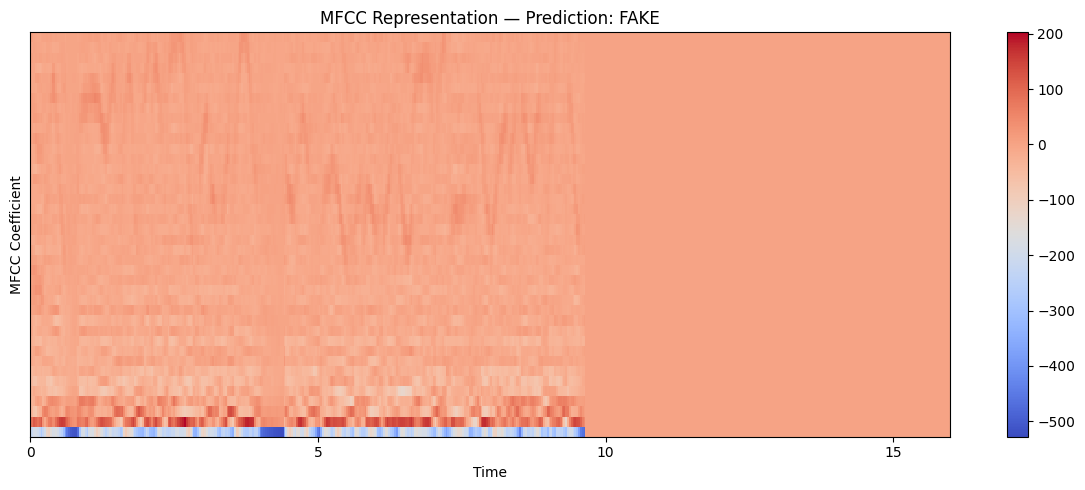

In [ ]:
result_fake = evaluate_audio("/content/wavefake_required/generated_audio/ljspeech_melgan/LJ001-0001_gen.wav")

Saving jackhammer.wav to jackhammer (4).wav
AUDIO INFORMATION
------------------------------------------------------------
File: jackhammer (4).wav
Sample rate: 16000 Hz
Duration: 3.35 seconds



DEEPFAKE DETECTION RESULT
------------------------------------------------------------
Prediction       : REAL
Real probability : 64.88%
Fake probability : 35.12%
Confidence       : 64.88%


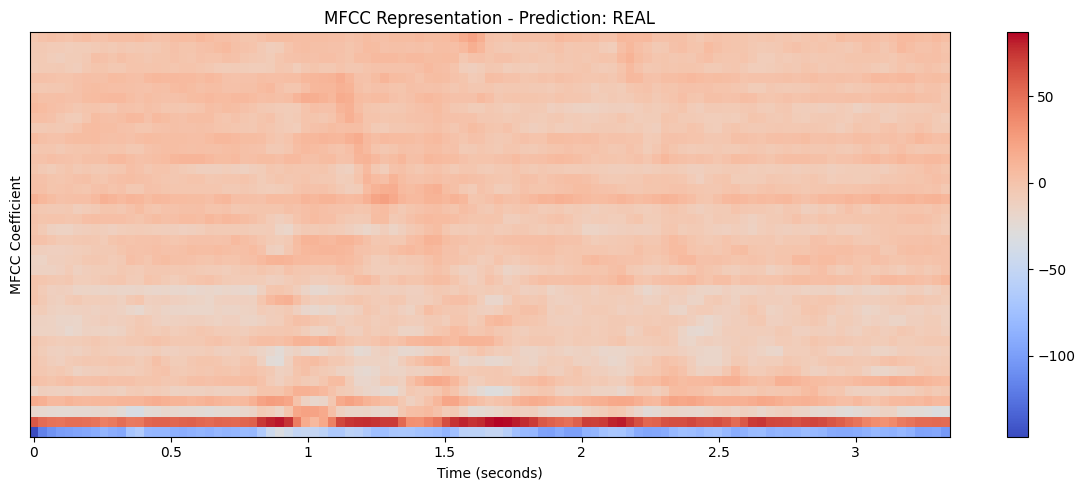

In [ ]:
uploaded = files.upload()

uploaded_file = next(iter(uploaded))

result = evaluate_audio(uploaded_file)